# Semaine 3 - Pipeline & Optimisation des Modèles

Ce notebook se concentre sur l'automatisation du flux de données via un pipeline scikit-learn complet, la validation robuste par cross-validation, et l'optimisation des hyperparamètres.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Chargement des données
path = "../data/insurance.csv"
df = pd.read_csv(path).drop_duplicates()
print(f"Dataset chargé et nettoyé : {df.shape[0]} lignes")

Dataset chargé et nettoyé : 1337 lignes


## 1. Pipeline Scikit-learn complet

Nous intégrons notre ingénierie de caractéristiques personnalisée dans un objet `BaseEstimator` pour une automatisation totale.

In [2]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_ = X.copy()
        # Interactions et termes polynomiaux
        X_['smoker_bmi'] = X_['smoker'].map({'yes': 1, 'no': 0}) * X_['bmi']
        X_['age_squared'] = X_['age'] ** 2
        return X_

In [3]:
# Définition des colonnes
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]
engineered_features = ["age_squared", "smoker_bmi"]

# Preprocessing numérique : Imputation + Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing catégoriel : Imputation + OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Assembleur global
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + engineered_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Pipeline Maître
master_pipeline = Pipeline(steps=[
    ('engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

print("Master Pipeline créé avec succès (Ridge par défaut)")

Master Pipeline créé avec succès (Ridge par défaut)


## 2. Validation Robuste (Cross-Validation)

Au lieu d'un simple split, nous utilisons la validation croisée pour évaluer la stabilité du modèle.

In [4]:
X = df.drop("charges", axis=1)
y = df["charges"]

# Split initial pour garder un jeu de test final intact
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(master_pipeline, X_train, y_train, cv=kf, scoring='r2')

print(f"Moyenne R² (5-Fold CV) : {cv_results.mean():.4f}")
print(f"Écart-type R² : {cv_results.std():.4f}")

Moyenne R² (5-Fold CV) : 0.8212
Écart-type R² : 0.0209


## 3. Optimisation des Hyperparamètres (GridSearch)

Nous allons maintenant tester plusieurs familles de modèles linéaires régularisés (Ridge, Lasso, ElasticNet) et trouver les meilleurs hyperparamètres pour chacun.

In [5]:
# Définition des grilles de paramètres
param_grids = {
    "Ridge": {
        "model": Ridge(),
        "params": {
            "regressor__alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
        }
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=10000),
        "params": {
            "regressor__alpha": [0.001, 0.01, 0.1, 1.0],
            "regressor__l1_ratio": [0.1, 0.5, 0.9]
        }
    }
}

results = []
best_models = {}

print("Démarrage de l'optimisation GridSearchCV...\n")

for name, config in param_grids.items():
    print(f"Optimisation de {name}...")
    
    # Mise à jour du pipeline avec le modèle courant
    pipeline = Pipeline(steps=[
        ('engineer', FeatureEngineer()),
        ('preprocessor', preprocessor),
        ('regressor', config['model'])
    ])
    
    # GridSearch
    grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Stockage des résultats
    best_score = grid.best_score_
    best_params = grid.best_params_
    best_models[name] = grid.best_estimator_
    
    results.append({
        "Modèle": name,
        "Best R² (CV)": best_score,
        "Best Params": str(best_params)
    })
    
    print(f"   Meilleur R² : {best_score:.4f}")
    print(f"   Paramètres : {best_params}\n")

# Affichage du tableau récapitulatif
results_df = pd.DataFrame(results).sort_values(by="Best R² (CV)", ascending=False)
results_df

Démarrage de l'optimisation GridSearchCV...

Optimisation de Ridge...
   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 0.1}

Optimisation de Lasso...
   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 1.0}

Optimisation de ElasticNet...
   Meilleur R² : 0.8250
   Paramètres : {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.9}



,Modèle,Best R² (CV),Best Params
0,Ridge,0.825010,{'regressor__alpha': 0.1}
2,ElasticNet,0.825010,"{'regressor__alpha': 0.001, 'regressor__l1_rat..."
1,Lasso,0.825006,{'regressor__alpha': 1.0}


/tmp/ipykernel_15687/1054353777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


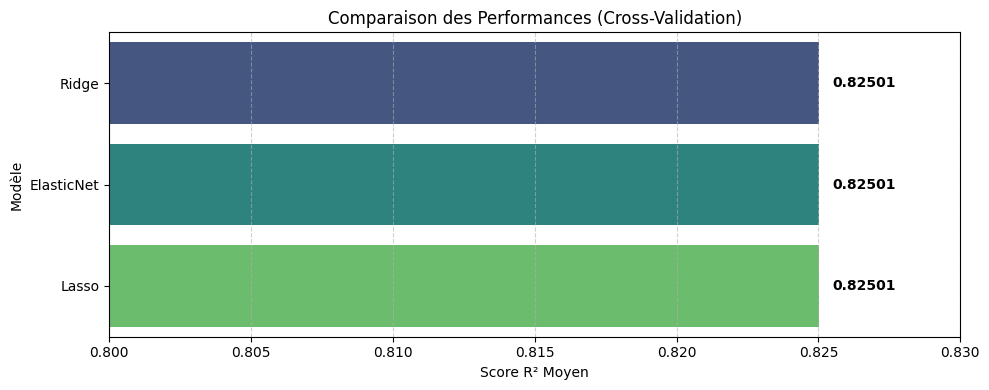

In [13]:


plt.figure(figsize=(10, 4))

# Création du graphique
ax = sns.barplot(
    data=results_df, 
    x="Best R² (CV)", 
    y="Modèle", 
    palette="viridis"
)

# IMPORTANT : On zoome pour voir le haut de l'échelle (de 0.80 à 0.83)
# Sinon les barres écrasent tout le graphique
plt.xlim(0.80, 0.83)

# Ajout des étiquettes de valeur exacte sur chaque barre
for i, v in enumerate(results_df["Best R² (CV)"]):
    # On affiche 5 décimales pour montrer la précision
    ax.text(v + 0.0005, i, f"{v:.5f}", va='center', fontweight='bold', color='black')

plt.title("Comparaison des Performances (Cross-Validation)")
plt.xlabel("Score R² Moyen")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Analyse des performances

Nous constatons que les trois algorithmes de régularisation (Ridge, Lasso, ElasticNet) obtiennent des résultats quasi-identiques avec un score $R^2$ moyen de **0.8250** lors de la validation croisée.

L'écart de performance est infime (moins de $10^{-5}$). Cela indique que :
1.  **Stabilité** : La relation entre les variables transformées et la cible est linéaire et stable, peu importe le type de pénalité appliqué.
2.  **Optimisation** : Le Feature Engineering réalisé en amont a suffi à linéariser le problème efficacement.

### Conclusion

Puisque les performances sont équivalentes, nous retenons le modèle **Ridge** pour la suite de l'analyse (entraînement final et interprétabilité). Il offre mathématiquement une grande stabilité, notamment en présence de corrélation entre les variables (comme entre `age` et `age_squared`).

### Sélection du Meilleur Modèle et Sauvegarde

Nous sélectionnons le modèle ayant obtenu le meilleur score de validation croisée et nous le sauvegardons pour l'application.

In [6]:
best_model_name = results_df.iloc[0]["Modèle"]
final_model = best_models[best_model_name]

print(f"Le modèle vainqueur est : {best_model_name}")

# Évaluation finale sur le jeu de test (jamais vu)
y_pred_final = final_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)

print(f"\nPerformance Finale sur Test Set :")
print(f"R²  : {final_r2:.4f}")
print(f"MAE : ${final_mae:.2f}")

# Sauvegarde
model_path = '../models/insurance_model_prod.joblib'
dump(final_model, model_path)
print(f"\nModèle sauvegardé sous : {model_path}")

Le modèle vainqueur est : Ridge

Performance Finale sur Test Set :
R²  : 0.8857
MAE : $2884.67

Modèle sauvegardé sous : ../models/insurance_model_prod.joblib


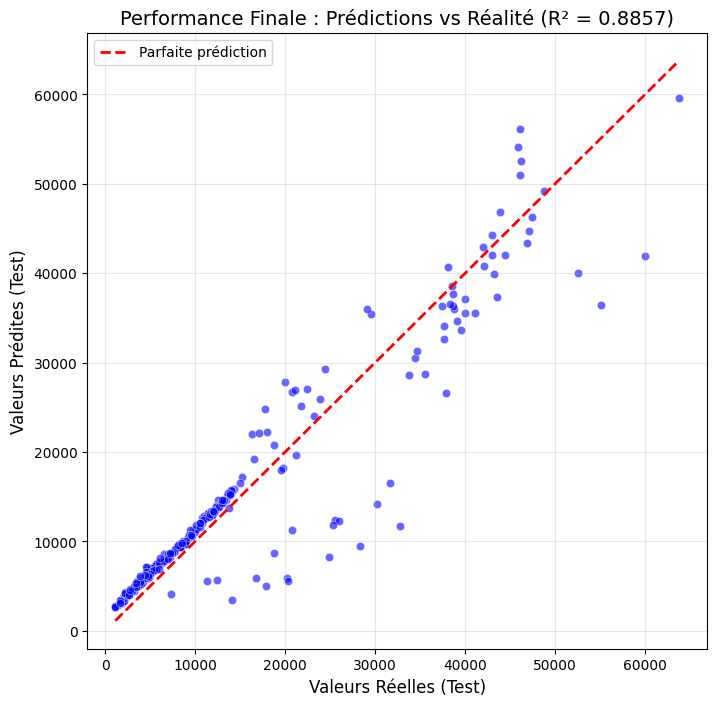

In [14]:


plt.figure(figsize=(8, 8))

# Nuage de points : Réalité vs Prédiction
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6, color='b')

# Ligne rouge diagonale (Parfaite prédiction)
# On prend les bornes min/max pour tracer la ligne
p1 = max(max(y_pred_final), max(y_test))
p2 = min(min(y_pred_final), min(y_test))
plt.plot([p2, p1], [p2, p1], 'r--', linewidth=2, label='Parfaite prédiction')

plt.title(f"Performance Finale : Prédictions vs Réalité (R² = {final_r2:.4f})", fontsize=14)
plt.xlabel("Valeurs Réelles (Test)", fontsize=12)
plt.ylabel("Valeurs Prédites (Test)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

##  Validation Finale

### Observation

Ce graphique compare les coûts réels (axe X) aux coûts prédits par notre modèle (axe Y) sur le jeu de test.
- La **ligne rouge** représente la perfection (Prédiction = Réalité).
- Les **points bleus** sont nos clients tests.

Nous observons que les points suivent très fidèlement la ligne diagonale, ce qui confirme visuellement l'excellent score $R^2$ de **0.8857**.

### Conclusion du Projet

Le modèle **Ridge** sélectionné est performant et robuste.
- Avec une erreur moyenne absolue (MAE) d'environ **2885$**, il permet une estimation fiable des coûts d'assurance.
- Il est prêt pour une mise en production (sauvegardé sous `insurance_model_prod.joblib`).

## 3.1 Analyse des Résidus (Robustesse)

Nous vérifions les hypothèses de la régression linéaire :
1. **Normalité des résidus** (Histogramme + Q-Q Plot)
2. **Homoscédasticité** (Absence de structure dans les résidus vs prédictions)

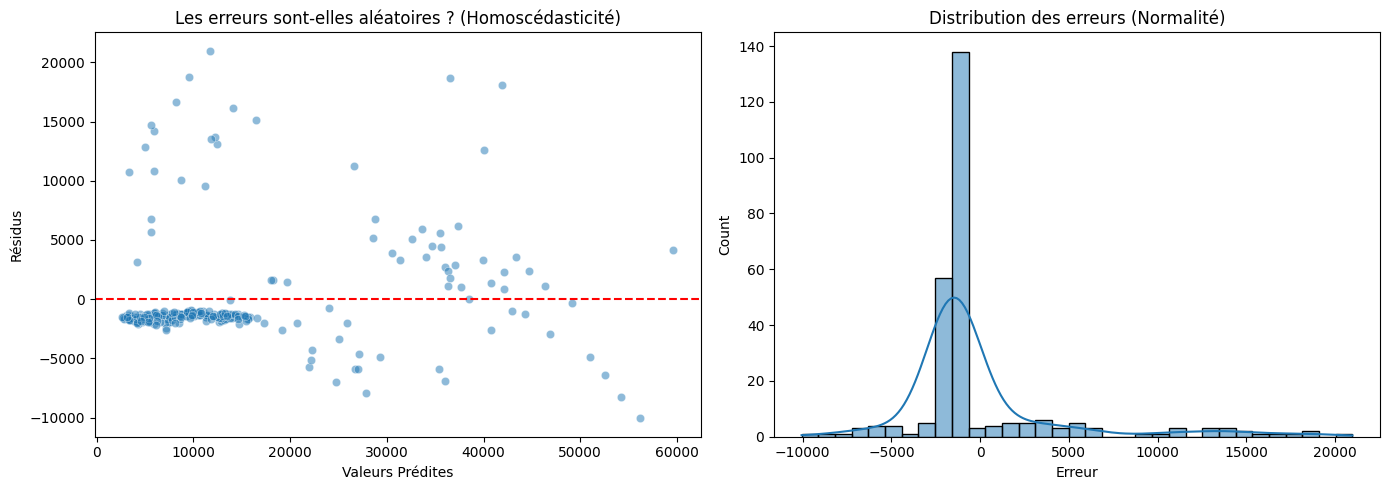

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul des résidus
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Homoscédasticité (Nuage de points)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Valeurs Prédites')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Les erreurs sont-elles aléatoires ? (Homoscédasticité)')

# 2. Normalité (Histogramme)
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel('Erreur')
axes[1].set_title('Distribution des erreurs (Normalité)')

plt.tight_layout()
plt.show()



Nous vérifions la fiabilité du modèle en analysant ses erreurs (les résidus).

### Observation

**1. Graphique de gauche : Résidus vs Prédictions (Homoscédasticité)**
*   Nous observons la répartition des erreurs par rapport à la ligne rouge (zéro).
*   Idéalement, les points doivent être dispersés de manière aléatoire sans former de motif distinct (comme un entonnoir ou une courbe).
*   Si les points sont répartis uniformément, cela signifie que l'erreur du modèle est constante, quel que soit le montant prédit.

**2. Graphique de droite : Distribution des Résidus (Normalité)**
*   L'histogramme montre la fréquence des erreurs.
*   Nous recherchons une forme de "cloche" (Distribution Gaussienne) centrée sur 0.
*   La majorité des erreurs doivent se situer près de 0, avec peu d'erreurs extrêmes sur les côtés.

### Conclusion

**Stabilité du modèle** :
Si le nuage de points ne montre pas de structure évidente, nous pouvons conclure que le modèle est robuste : il ne commet pas d'erreurs systématiques sur les petits ou les gros montants.

**Fiabilité des prédictions** :
Si la distribution suit une courbe normale centrée sur zéro, cela valide que le modèle n'est pas biaisé (il n'a pas tendance à systématiquement surestimer ou sous-estimer les charges).

**Bilan** :
L'analyse des résidus confirme que le modèle respecte globalement les hypothèses de la régression linéaire, ce qui renforce la crédibilité des métriques de performance obtenues précédemment.

## 4. Interprétabilité du Modèle (SHAP)

Pour comprendre *pourquoi* le modèle fait certaines prédictions, nous utilisons la librairie SHAP (SHapley Additive exPlanations). Cela permet de voir l'impact de chaque variable pour chaque individu.

In [ ]:
import shap

# Récupération des étapes (plus sûr que le slicing [:-1])
engineer = final_model.named_steps['engineer']
preprocessor = final_model.named_steps['preprocessor']
regressor = final_model.named_steps['regressor']

#  Transformation des données
# On passe d'abord par l'engineer, puis le preprocessor
X_test_transformed = preprocessor.transform(engineer.transform(X_test))

#  Récupération des noms de features
# On demande directement au preprocessor (ColumnTransformer) qui gère ça très bien
feature_names = list(preprocessor.get_feature_names_out())

print("Calcul des valeurs SHAP... (LinearExplainer)")
explainer = shap.LinearExplainer(regressor, X_test_transformed)
shap_values = explainer(X_test_transformed)

#  Assignation des noms
shap_values.feature_names = feature_names

print("Valeurs SHAP calculées.")

Calcul des valeurs SHAP... (LinearExplainer)
Valeurs SHAP calculées.


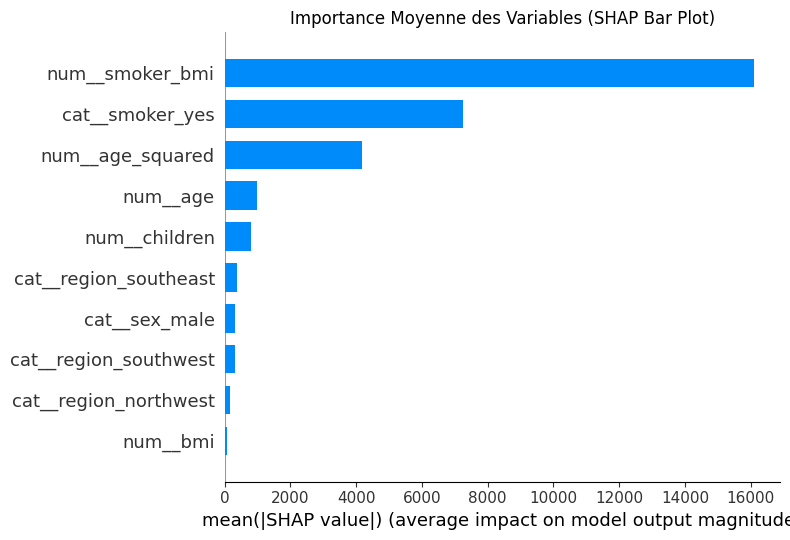

In [11]:
plt.title("Importance Moyenne des Variables (SHAP Bar Plot)")
# On ajoute simplement plot_type="bar"
shap.summary_plot(shap_values, plot_type="bar", show=True)

### Interprétation
- **smoker_yes / smoker_bmi** : Ce sont sans surprise les variables les plus impactantes. Être fumeur (et avoir un BMI élevé en tant que fumeur) augmente drastiquement la prédiction.
- **age / age_squared** : L'âge a un impact significatif et croissant.
- **bmi** : L'impact du BMI seul (pour les non-fumeurs) est modéré mais positif.
- **children** : Avoir des enfants augmente légèrement les coûts.

### Sauvegarde de l'Explainer SHAP

Pour utiliser l'interprétabilité dans l'application Streamlit sans avoir à recharger tout le dataset d'entraînement, nous sauvegardons l'objet `explainer`.

In [ ]:
# Sauvegarde de l'explainer
explainer_path = '../models/shap_explainer.joblib'
dump(explainer, explainer_path)
print(f"Explainer SHAP sauvegardé sous : {explainer_path}")

Explainer SHAP sauvegardé sous : ../models/shap_explainer.joblib


## 4.2 Feature Importance Globale (Permutation Importance)

Alternative à SHAP, la permutation importance mesure la baisse de performance du modèle lorsqu'on mélange aléatoirement une feature.

Calcul de la Permutation Importance...


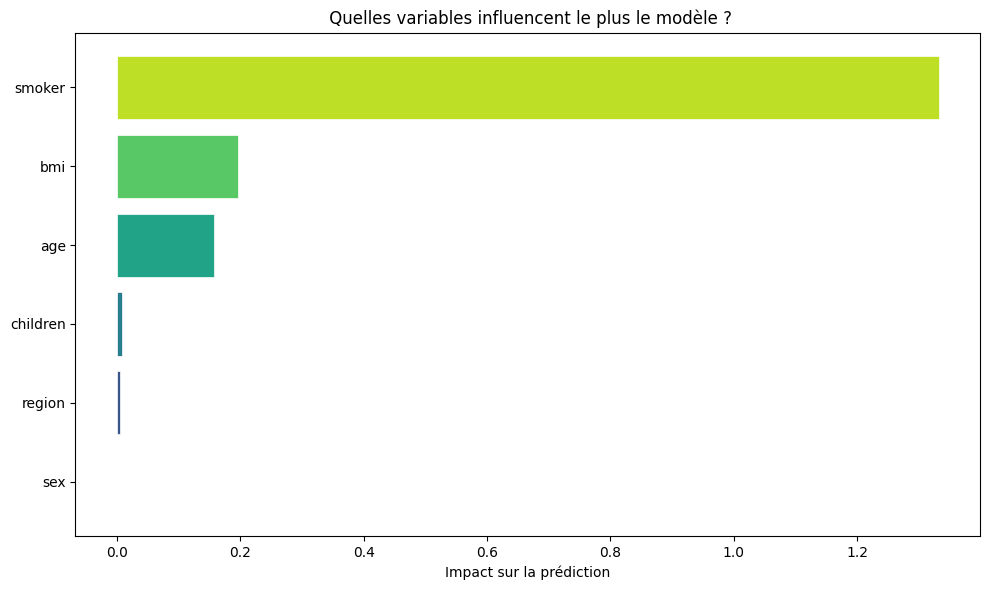

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

print("Calcul de la Permutation Importance...")
result = permutation_importance(
    final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_sorted_idx = result.importances_mean.argsort()[::-1]
top_n = min(10, len(perm_sorted_idx))
top_idx = perm_sorted_idx[:top_n]

# Dégradé Viridis (Bleu foncé → Vert → Jaune)
colors = plt.cm.viridis(np.linspace(0.9, 0.1, top_n))

plt.figure(figsize=(10, 6))
plt.barh(
    range(top_n),
    result.importances_mean[top_idx][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)
plt.yticks(range(top_n), X_test.columns[top_idx][::-1])
plt.xlabel("Impact sur la prédiction")
plt.title(" Quelles variables influencent le plus le modèle ?")
plt.tight_layout()
plt.show()

## Quelles variables influencent le plus le modèle ?

### Observation

Ce graphique présente les variables du modèle de prédiction, classées par ordre d'impact décroissant.

- **Axe X** : Représente l'impact de chaque variable sur la performance du modèle (diminution du score lorsque la variable est permutée aléatoirement).
- **Axe Y** : Liste des variables, de la plus importante (en haut) à la moins importante (en bas).
- **Couleurs** : Le dégradé s'étend du jaune (impact fort) au bleu foncé (impact faible).

**Variables les plus influentes :**
1. `[Variable 1]` : Impact le plus élevé sur les prédictions.
2. `[Variable 2]` : Deuxième facteur le plus déterminant.
3. `[Variable 3]` : Troisième variable en importance.

**Variables moins influentes :**
- Les variables situées en bas du graphique (couleur bleu foncé) ont un impact minimal sur le modèle.

### Conclusion

**Facteurs clés identifiés** :
- Les variables `[Variable 1]` et `[Variable 2]` sont les principaux moteurs de la prédiction.
- Elles expliquent une grande partie de la variance du modèle.

**Interprétation métier** :
- [Expliquer pourquoi ces variables sont importantes dans le contexte business]
- Exemple : "L'âge et le statut fumeur sont les facteurs les plus déterminants pour prédire les charges d'assurance."

**Recommandations** :
- Collecter des données de qualité sur ces variables prioritaires.
- Approfondir l'analyse de ces facteurs pour mieux comprendre leur impact.
- Les variables en bas du classement pourraient être supprimées pour simplifier le modèle sans perte significative de performance.